# Аналитика и визуализация начислений ЖКУ (ЕПД МосОблЕИРЦ)

Данный ноутбук содержит примеры аналитических SQL-запросов к оцифрованным квитанциям из базы данных SQLite `db/receipts.db` и построение графиков:
- 📊 Динамика общей суммы платежей по месяцам
- 🥧 Структура расходов по категориям (жилищные, коммунальные, иные услуги)
- 🌡️ Анализ сезонного потребления отопления (Гкал и рубли)
- ⚡ Динамика потребления ресурсов (электроэнергия, водоотведение)
- 🏆 Рейтинг самых затратных услуг за весь период
- 🥇 Топ-3 самых затратных услуг по годам (с долями в % от годовых расходов)
- 📈 Распределение начислений по категориям услуг в разрезе годов
- 🔍 Сведения о перерасчетах


In [35]:
import sqlite3
from pathlib import Path

# Проверяем наличие библиотек pandas и matplotlib
try:
    import pandas as pd
    import matplotlib.pyplot as plt
    import matplotlib.ticker as ticker
    plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
    plt.rcParams["figure.figsize"] = (10, 5)
    plt.rcParams["font.size"] = 10
    HAS_PLOT_LIBS = True
except ImportError:
    HAS_PLOT_LIBS = False
    print("Для отображения графиков установите pandas и matplotlib: pip install pandas matplotlib")

# Путь к базе данных receipts.db
DB_PATH = Path("..") / "db" / "receipts.db"
conn = sqlite3.connect(str(DB_PATH))
conn.row_factory = sqlite3.Row
print(f"Подключено к базе данных: {DB_PATH.resolve()}")

Подключено к базе данных: D:\PyProjects\_my\pdf_table_parcer\db\receipts.db


---
## 1. Лицевой счет и реестр загруженных квитанций

In [36]:
cursor = conn.cursor()
account = cursor.execute("SELECT * FROM accounts LIMIT 1").fetchone()
if account:
    print(f"Лицевой счет: {account['account_number']}")
    print(f"Плательщик:   {account['payer_name']}")
    print(f"Адрес:        {account['address']}\n")

# Список загруженных квитанций
if HAS_PLOT_LIBS:
    df_receipts = pd.read_sql_query(
        "SELECT id, period, period_date, total_to_pay, source_file FROM receipts ORDER BY period_date;",
        conn
    )
    display(df_receipts)
else:
    rows = cursor.execute("SELECT id, period, period_date, total_to_pay FROM receipts ORDER BY period_date;").fetchall()
    for r in rows:
        print(dict(r))

Лицевой счет: 32546-580
Плательщик:   БЕГМА МАКСИМ ВАЛЕНТИНОВИЧ
Адрес:        141102, МОСКОВСКАЯ ОБЛ., Г.О. ЩЁЛКОВО, Г ЩЁЛКОВО, УЛ ШМИДТА, д.1, кв.244



,id,period,period_date,total_to_pay,source_file
0,14,январь 2025,2025-01-01,15593.17,01 2025.pdf
1,15,февраль 2025,2025-02-01,15630.20,02 2025.pdf
2,16,март 2025,2025-03-01,14980.09,03 2025.pdf
3,17,апрель 2025,2025-04-01,14112.21,04 2025.pdf
4,18,май 2025,2025-05-01,12715.53,05 2025.pdf
5,19,июнь 2025,2025-06-01,9841.33,06 2025.pdf
6,20,июль 2025,2025-07-01,9558.61,07 2025.pdf
7,21,август 2025,2025-08-01,9833.63,08 2025.pdf
8,10,сентябрь 2025,2025-09-01,11698.69,09 2025.pdf
9,11,октябрь 2025,2025-10-01,16411.00,10 2025.pdf


---
## 2. Динамика общей суммы начислений по месяцам
График общей суммы к оплате (без учета добровольного страхования) с января по сентябрь 2026 года.

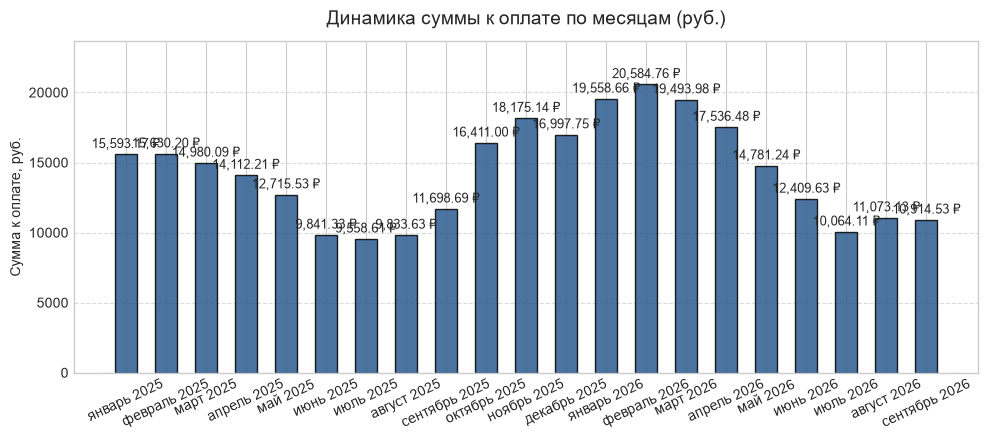

In [37]:
query_totals = """
    SELECT period_date, period, total_to_pay
    FROM receipts
    ORDER BY period_date;
"""

if HAS_PLOT_LIBS:
    df_totals = pd.read_sql_query(query_totals, conn)
    
    fig, ax = plt.subplots(figsize=(10, 4.5))
    x_pos = range(len(df_totals))
    bars = ax.bar(x_pos, df_totals["total_to_pay"], color="#2b5c8f", width=0.55, edgecolor="black", alpha=0.85)
    
    ax.set_title("Динамика суммы к оплате по месяцам (руб.)", fontsize=14, pad=12)
    ax.set_ylabel("Сумма к оплате, руб.")
    ax.set_xticks(x_pos)
    ax.set_xticklabels(df_totals["period"], rotation=25)
    ax.grid(axis="y", linestyle="--", alpha=0.7)
    
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, yval + 250, f"{yval:,.2f} ₽", ha="center", va="bottom", fontsize=9)
    
    ax.set_ylim(0, df_totals["total_to_pay"].max() * 1.15)
    plt.tight_layout()
    plt.show()
else:
    for r in conn.execute(query_totals):
        print(f"{r['period']}: {r['total_to_pay']} руб.")


---
## 3. Распределение начислений по категориям услуг
Сравнение долей жилищных, коммунальных и иных услуг в общей сумме начислений.

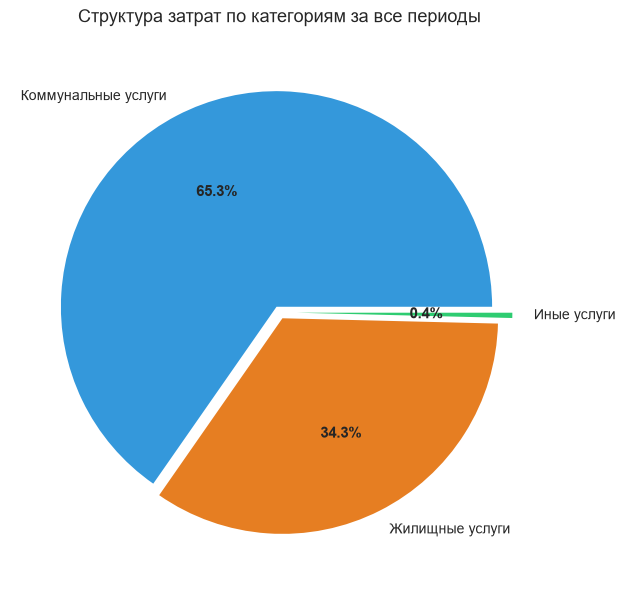

In [38]:
query_categories = """
    SELECT service_category, ROUND(SUM(total_amount), 2) AS category_sum
    FROM service_charges
    GROUP BY service_category
    ORDER BY category_sum DESC;
"""

if HAS_PLOT_LIBS:
    df_cats = pd.read_sql_query(query_categories, conn)
    
    fig, ax = plt.subplots(figsize=(7, 7))
    colors = ["#3498db", "#e67e22", "#2ecc71"]
    wedges, texts, autotexts = ax.pie(
        df_cats["category_sum"],
        labels=df_cats["service_category"],
        autopct="%1.1f%%",
        startangle=0,
        colors=colors,
        explode=[0.03, 0.03, 0.08],
        shadow=False
    )
    for at in autotexts:
        at.set_fontsize(11)
        at.set_weight("bold")
        
    ax.set_title("Структура затрат по категориям за все периоды", fontsize=13, pad=15)
    plt.show()
else:
    for r in conn.execute(query_categories):
        print(dict(r))

---
## 4. Сезонный анализ отопления
Динамика расхода (Гкал) и суммы начислений за отопление по месяцам (демонстрирует окончание отопительного периода весной).

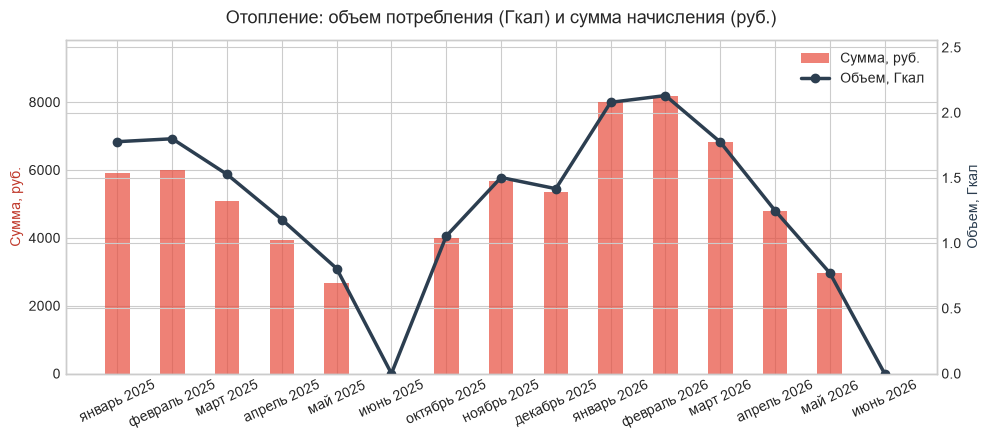

In [39]:
query_heating = """
    SELECT r.period, r.period_date, sc.volume, sc.tariff, sc.total_amount
    FROM service_charges sc
    JOIN receipts r ON sc.receipt_id = r.id
    WHERE sc.service_name LIKE '%ОТОПЛЕНИЕ%'
    ORDER BY r.period_date;
"""

if HAS_PLOT_LIBS:
    df_heating = pd.read_sql_query(query_heating, conn)
    
    fig, ax1 = plt.subplots(figsize=(10, 4.5))
    ax2 = ax1.twinx()
    x_pos = range(len(df_heating))
    
    bars = ax1.bar(x_pos, df_heating["total_amount"], color="#e74c3c", alpha=0.7, width=0.45, label="Сумма, руб.")
    line = ax2.plot(x_pos, df_heating["volume"], color="#2c3e50", marker="o", linewidth=2.5, label="Объем, Гкал")
    
    ax1.set_title("Отопление: объем потребления (Гкал) и сумма начисления (руб.)", fontsize=13, pad=12)
    ax1.set_ylabel("Сумма, руб.", color="#c0392b")
    ax2.set_ylabel("Объем, Гкал", color="#2c3e50")
    ax1.set_ylim(0, df_heating["total_amount"].max() * 1.2)
    ax2.set_ylim(0, df_heating["volume"].max() * 1.2)
    
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(df_heating["period"], rotation=25)
    
    # Объединенная легенда
    lines = [bars, line[0]]
    labels = ["Сумма, руб.", "Объем, Гкал"]
    ax1.legend(lines, labels, loc="upper right")
    
    fig.tight_layout()
    plt.show()
else:
    for r in conn.execute(query_heating):
        print(dict(r))


---
## 5. Динамика расхода электроэнергии и водоотведения
Отслеживание объемов потребления ресурсов в физических величинах (кВт*ч и куб.м).

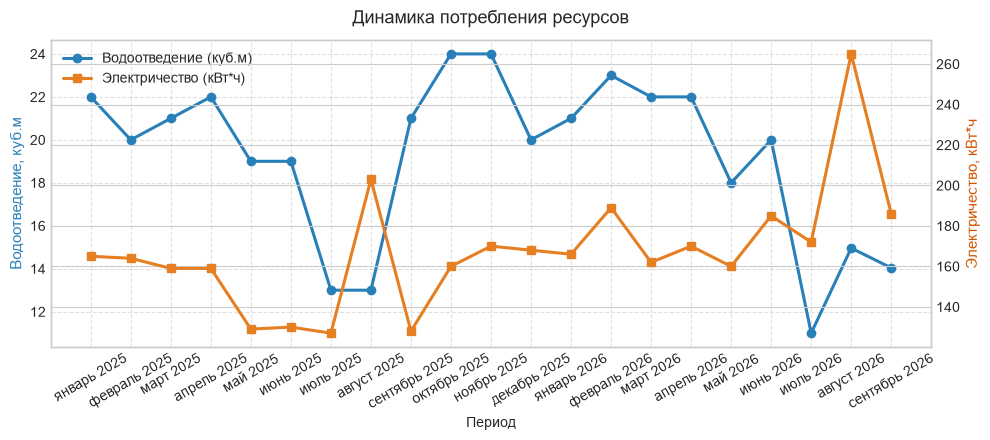

In [40]:
query_resources = """
    SELECT r.period_date, r.period, sc.service_name, sc.volume, sc.unit
    FROM service_charges sc
    JOIN receipts r ON sc.receipt_id = r.id
    WHERE sc.service_name LIKE '%ЭЛЕКТРИЧЕСТВО%' OR sc.service_name = 'ВОДООТВЕДЕНИЕ'
    ORDER BY r.period_date;
"""

if HAS_PLOT_LIBS:
    df_res = pd.read_sql_query(query_resources, conn)
    
    # Сводная таблица по period_date для сохранения строгого хронологического порядка
    pivot_res = df_res.pivot(index="period_date", columns="service_name", values="volume").sort_index()
    
    # Соответствие дат и названий месяцев для подписей оси X
    period_map = df_res.drop_duplicates("period_date").set_index("period_date")["period"]
    x_labels = [period_map.get(d, d) for d in pivot_res.index]
    x_indices = range(len(pivot_res))
    
    # Поиск колонок водоотведения и электроэнергии
    water_cols = [c for c in pivot_res.columns if "ВОДООТВЕДЕНИЕ" in c]
    elec_cols = [c for c in pivot_res.columns if "ЭЛЕКТРИЧЕСТВО" in c]
    water_col = water_cols[0] if water_cols else pivot_res.columns[0]
    elec_col = elec_cols[0] if elec_cols else pivot_res.columns[-1]
    
    # Построение графика с двумя осями Y (т.к. масштабы кВт*ч и куб.м сильно отличаются)
    fig, ax1 = plt.subplots(figsize=(10, 4.5))
    ax2 = ax1.twinx()
    
    line1 = ax1.plot(x_indices, pivot_res[water_col], marker="o", color="#2980b9", linewidth=2.2, label="Водоотведение (куб.м)")
    line2 = ax2.plot(x_indices, pivot_res[elec_col], marker="s", color="#e67e22", linewidth=2.2, label="Электричество (кВт*ч)")
    
    ax1.set_title("Динамика потребления ресурсов", fontsize=13, pad=12)
    ax1.set_xlabel("Период")
    ax1.set_ylabel("Водоотведение, куб.м", color="#2980b9", fontsize=11)
    ax2.set_ylabel("Электричество, кВт*ч", color="#d35400", fontsize=11)
    
    ax1.set_xticks(x_indices)
    ax1.set_xticklabels(x_labels, rotation=30)
    ax1.grid(True, linestyle="--", alpha=0.6)
    
    # Объединенная легенда
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc="upper left")
    
    fig.tight_layout()
    plt.show()
else:
    for r in conn.execute(query_resources):
        print(dict(r))


---
## 6. Топ-10 самых затратных услуг за весь период

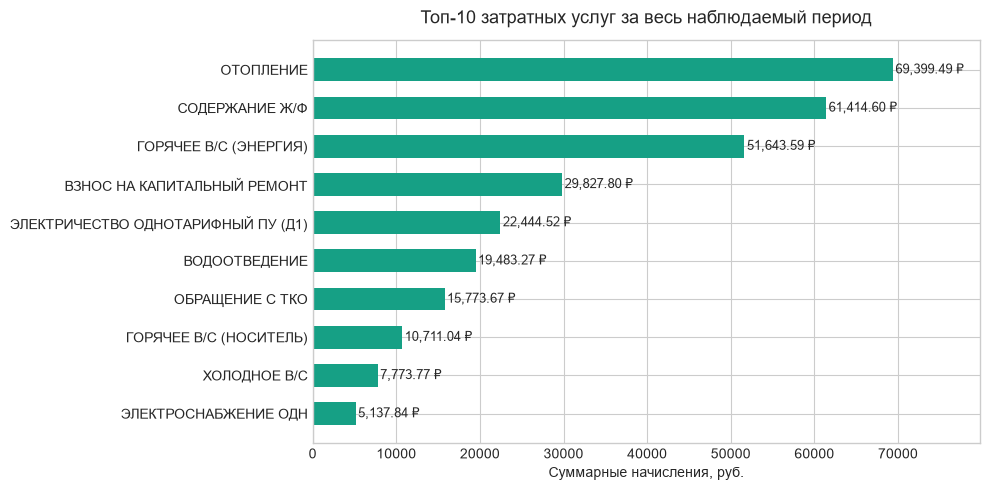

In [41]:
query_top = """
    SELECT service_name, ROUND(SUM(total_amount), 2) AS total_sum
    FROM service_charges
    GROUP BY service_name
    ORDER BY total_sum DESC
    LIMIT 10;
"""

if HAS_PLOT_LIBS:
    df_top = pd.read_sql_query(query_top, conn)
    
    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.barh(df_top["service_name"][::-1], df_top["total_sum"][::-1], color="#16a085", height=0.6)
    
    ax.set_title("Топ-10 затратных услуг за весь наблюдаемый период", fontsize=13, pad=12)
    ax.set_xlabel("Суммарные начисления, руб.")
    
    for bar in bars:
        w = bar.get_width()
        ax.text(w + 300, bar.get_y() + bar.get_height() / 2, f"{w:,.2f} ₽", va="center", fontsize=9)
        
    ax.set_xlim(0, df_top["total_sum"].max() * 1.15)
    plt.tight_layout()
    plt.show()
else:
    for r in conn.execute(query_top):
        print(f"{r['service_name']}: {r['total_sum']} руб.")

---
## 7. Сведения о перерасчетах
Выборка всех услуг, по которым производились перерасчеты (`recalculation != 0`).

In [42]:
query_recalc = """
    SELECT r.period, sc.service_name, sc.recalculation, sc.total_amount
    FROM service_charges sc
    JOIN receipts r ON sc.receipt_id = r.id
    WHERE ABS(sc.recalculation) > 0.01
    ORDER BY r.period_date, sc.service_name;
"""

if HAS_PLOT_LIBS:
    df_recalc = pd.read_sql_query(query_recalc, conn)
    if not df_recalc.empty:
        display(df_recalc)
    else:
        print("Перерасчетов за данный период не обнаружено.")
else:
    rows = conn.execute(query_recalc).fetchall()
    for r in rows:
        print(dict(r))

,period,service_name,recalculation,total_amount
0,май 2025,ВОДООТВЕДЕНИЕ ОДН,194.82,199.54
1,май 2025,ХОЛОДНОЕ В/С ОДН,217.78,220.34
2,май 2025,ЭЛЕКТРОСНАБЖЕНИЕ ОДН,66.08,236.04
3,июнь 2025,ВОДООТВЕДЕНИЕ ОДН,194.82,199.54
4,июнь 2025,ХОЛОДНОЕ В/С ОДН,217.78,220.34
5,июнь 2025,ЭЛЕКТРОСНАБЖЕНИЕ ОДН,66.08,236.04
6,июль 2025,ВОДООТВЕДЕНИЕ ОДН,194.82,200.56
7,июль 2025,ХОЛОДНОЕ В/С ОДН,217.78,220.39
8,июль 2025,ЭЛЕКТРОСНАБЖЕНИЕ ОДН,66.08,267.47
9,август 2025,ВОДООТВЕДЕНИЕ ОДН,194.82,200.56


---
## 8. Топ-3 самых затратных услуг по годам
Сравнение трех ключевых статей расходов в квитанциях за каждый год с расчетом суммы начислений и их процентной доли в годовом бюджете ЖКХ.


,Год,Место,Услуга,"Сумма, руб.","Доля, %"
0,2025,1,ОТОПЛЕНИЕ,38625.38,23.3
1,2025,2,СОДЕРЖАНИЕ Ж/Ф,33817.78,20.4
2,2025,3,ГОРЯЧЕЕ В/С (ЭНЕРГИЯ),27918.43,16.9
3,2026,1,ОТОПЛЕНИЕ,30774.11,22.6
4,2026,2,СОДЕРЖАНИЕ Ж/Ф,27596.82,20.2
5,2026,3,ГОРЯЧЕЕ В/С (ЭНЕРГИЯ),23725.16,17.4


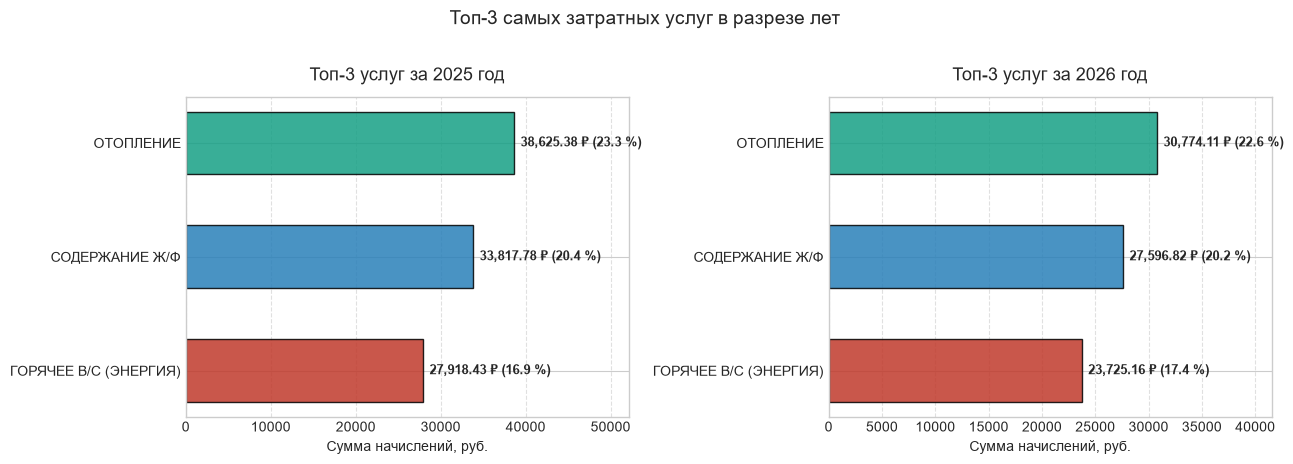

In [43]:
query_top3_yearly = """
WITH year_totals AS (
    SELECT year, SUM(total_amount) AS year_sum
    FROM service_charges sc
    JOIN receipts r ON sc.receipt_id = r.id
    GROUP BY year
),
ranked_services AS (
    SELECT 
        r.year,
        sc.service_name,
        ROUND(SUM(sc.total_amount), 2) AS total_sum,
        ROUND(SUM(sc.total_amount) * 100.0 / yt.year_sum, 1) AS share_percent,
        ROW_NUMBER() OVER (PARTITION BY r.year ORDER BY SUM(sc.total_amount) DESC) AS rank
    FROM service_charges sc
    JOIN receipts r ON sc.receipt_id = r.id
    JOIN year_totals yt ON r.year = yt.year
    GROUP BY r.year, sc.service_name
)
SELECT year AS 'Год', rank AS 'Место', service_name AS 'Услуга', total_sum AS 'Сумма, руб.', share_percent AS 'Доля, %'
FROM ranked_services
WHERE rank <= 3
ORDER BY year, rank;
"""

if HAS_PLOT_LIBS:
    df_top3 = pd.read_sql_query(query_top3_yearly, conn)
    display(df_top3)
    
    # Построение графиков для каждого года
    years = sorted(df_top3['Год'].unique())
    fig, axes = plt.subplots(1, len(years), figsize=(6.5 * len(years), 4.5), sharey=False)
    if len(years) == 1:
        axes = [axes]
        
    colors = ['#c0392b', '#2980b9', '#16a085']
    
    for idx, year in enumerate(years):
        ax = axes[idx]
        df_y = df_top3[df_top3['Год'] == year].copy()
        
        # Сортируем снизу вверх для горизонтального графика
        df_y = df_y.iloc[::-1]
        y_pos = range(len(df_y))
        
        bars = ax.barh(y_pos, df_y['Сумма, руб.'], color=colors, height=0.55, edgecolor='black', alpha=0.85)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(df_y['Услуга'], fontsize=10)
        ax.set_title(f"Топ-3 услуг за {year} год", fontsize=13, pad=12)
        ax.set_xlabel("Сумма начислений, руб.")
        ax.grid(axis='x', linestyle='--', alpha=0.6)
        
        max_val = df_y['Сумма, руб.'].max()
        ax.set_xlim(0, max_val * 1.35)
        
        for bar, (_, row) in zip(bars, df_y.iterrows()):
            w = bar.get_width()
            label_text = f"{w:,.2f} ₽ ({row['Доля, %']} %)"
            ax.text(w + max_val * 0.02, bar.get_y() + bar.get_height() / 2, label_text, va='center', fontsize=9.5, fontweight='bold')
            
    fig.suptitle("Топ-3 самых затратных услуг в разрезе лет", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    rows = conn.execute(query_top3_yearly).fetchall()
    for r in rows:
        print(dict(r))


---
## 9. Распределение начислений по категориям услуг в разрезе годов
Сравнение начислений по жилищным, коммунальным и иным услугам для каждого года: абсолютные суммы в рублях и соотношение процентных долей.


,Год,Категория,"Сумма, руб.","Доля, %"
0,2025,Коммунальные услуги,108412.45,65.5
1,2025,Жилищные услуги,56504.90,34.1
2,2025,Иные услуги,630.00,0.4
3,2026,Коммунальные услуги,88816.90,65.1
4,2026,Жилищные услуги,47044.62,34.5
5,2026,Иные услуги,555.00,0.4


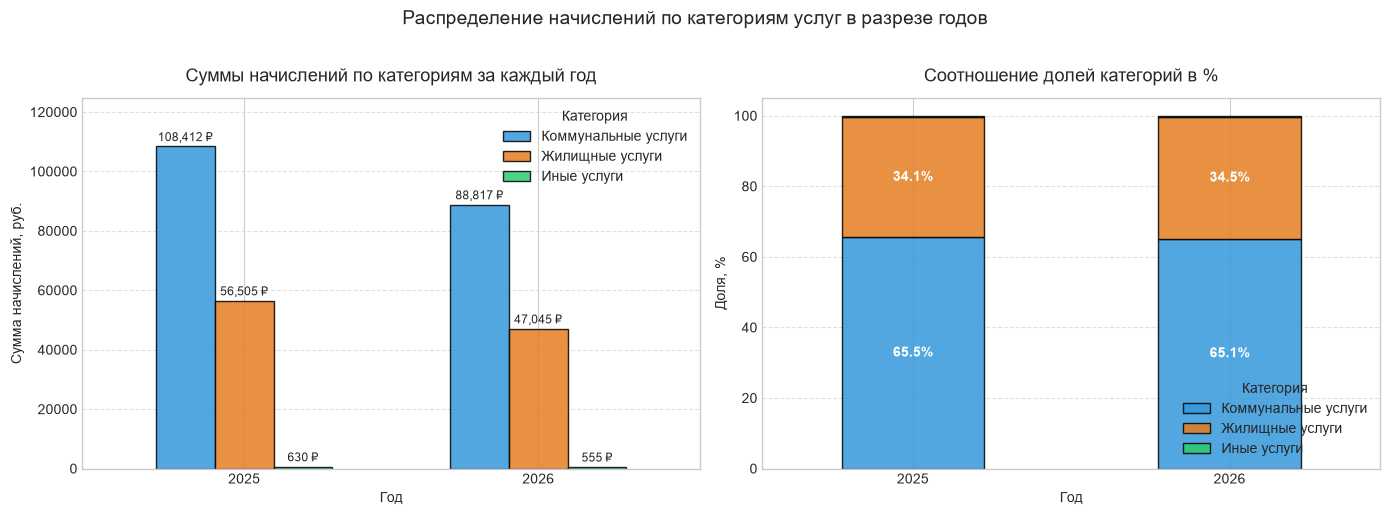

In [44]:
query_cat_yearly = """
WITH year_totals AS (
    SELECT year, SUM(total_amount) AS total_year
    FROM service_charges sc
    JOIN receipts r ON sc.receipt_id = r.id
    GROUP BY year
)
SELECT 
    r.year AS 'Год',
    sc.service_category AS 'Категория',
    ROUND(SUM(sc.total_amount), 2) AS 'Сумма, руб.',
    ROUND(SUM(sc.total_amount) * 100.0 / yt.total_year, 1) AS 'Доля, %'
FROM service_charges sc
JOIN receipts r ON sc.receipt_id = r.id
JOIN year_totals yt ON r.year = yt.year
GROUP BY r.year, sc.service_category
ORDER BY r.year, SUM(sc.total_amount) DESC;
"""

if HAS_PLOT_LIBS:
    df_cat_year = pd.read_sql_query(query_cat_yearly, conn)
    display(df_cat_year)
    
    # Сводные таблицы по суммам и долям
    pivot_sum = df_cat_year.pivot(index='Год', columns='Категория', values='Сумма, руб.')
    pivot_share = df_cat_year.pivot(index='Год', columns='Категория', values='Доля, %')
    
    # Фиксированный порядок категорий для легенды и цветов
    cat_order = [c for c in ['Коммунальные услуги', 'Жилищные услуги', 'Иные услуги'] if c in pivot_sum.columns]
    pivot_sum = pivot_sum[cat_order]
    pivot_share = pivot_share[cat_order]
    
    colors = ['#3498db', '#e67e22', '#2ecc71']
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # 1. Абсолютные суммы начислений по годам (руб.)
    pivot_sum.plot(kind='bar', ax=ax1, color=colors, width=0.6, edgecolor='black', alpha=0.85)
    ax1.set_title("Суммы начислений по категориям за каждый год", fontsize=13, pad=12)
    ax1.set_ylabel("Сумма начислений, руб.")
    ax1.set_xlabel("Год")
    ax1.set_xticklabels(pivot_sum.index, rotation=0)
    ax1.grid(axis='y', linestyle='--', alpha=0.6)
    ax1.legend(title="Категория", loc="upper right")
    
    # Подписи сумм над столбцами
    for p in ax1.patches:
        height = p.get_height()
        if height > 0:
            ax1.annotate(f"{height:,.0f} ₽",
                         (p.get_x() + p.get_width() / 2., height),
                         ha='center', va='bottom', fontsize=8.5,
                         xytext=(0, 2), textcoords='offset points')
    ax1.set_ylim(0, pivot_sum.values.max() * 1.15)
    
    # 2. Структура долей в процентах (100% Stacked Bar)
    pivot_share.plot(kind='bar', stacked=True, ax=ax2, color=colors, width=0.45, edgecolor='black', alpha=0.85)
    ax2.set_title("Соотношение долей категорий в %", fontsize=13, pad=12)
    ax2.set_ylabel("Доля, %")
    ax2.set_xlabel("Год")
    ax2.set_xticklabels(pivot_share.index, rotation=0)
    ax2.set_ylim(0, 105)
    ax2.grid(axis='y', linestyle='--', alpha=0.6)
    ax2.legend(title="Категория", loc="lower right")
    
    # Подписи процентов внутри стека
    for n, year in enumerate(pivot_share.index):
        cum_height = 0
        for col in cat_order:
            val = pivot_share.loc[year, col]
            if val > 3.0:
                ax2.text(n, cum_height + val / 2, f"{val:.1f}%",
                         ha='center', va='center', fontsize=10, fontweight='bold', color='white')
            cum_height += val
            
    fig.suptitle("Распределение начислений по категориям услуг в разрезе годов", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    for r in conn.execute(query_cat_yearly):
        print(dict(r))
